<h1>My Deep Learning Project: Household Electric Power Consumption Forecasting using LSTM in PyTorch</h1>

---

### Project Overview
In this project, I am building a <b>Long Short-Term Memory (LSTM)</b> network in <b>PyTorch</b> to forecast daily household electricity consumption (<b>Global Active Power</b> in kilowatts)!

While traditional Recurrent Neural Networks (RNN) suffer from <b>vanishing gradients</b> when processing long sequences, <b>LSTM networks</b> solve this memory problem using special internal <b>gating mechanisms</b> (Forget Gate, Input Gate, Output Gate) and a long-term <b>Cell State</b>!

---

### Key Concepts Covered:
- <b>✅ PyTorch Framework</b>: Tensors, <code>Dataset</code>, <code>DataLoader</code>, CUDA GPU acceleration
- <b>✅ Dataset Download</b>: Using <code>kagglehub.dataset_download("uciml/electric-power-consumption-data-set")</code>
- <b>✅ Data Cleaning & Resampling</b>: Converting minute-level electricity readings into daily mean power consumption.
- <b>✅ Time-Series Scaling</b>: <code>MinMaxScaler</code> normalization (scaling power values between 0 and 1).
- <b>✅ Sliding Window Sequences</b>: Creating <code>30-day</code> historical lookback sequences to predict the next day's electricity usage.
- <b>✅ Long Short-Term Memory (LSTM) Architecture</b>:
  - <code>nn.LSTM(input_size=1, hidden_size=64, num_layers=1, batch_first=True)</code>: Long-term cell state ($c_t$) and hidden state ($h_t$) memory.
  - <code>nn.Linear(64, 1)</code>: Fully connected linear output layer.
- <b>✅ Loss Function & Optimizer</b>: <code>nn.MSELoss</code> (Mean Squared Error) and <code>torch.optim.Adam</code>.
- <b>✅ Model Training & Diagnostic Plots</b>: Training loop, loss curves, test set forecasting, inverse feature scaling, and plotting <b>Actual vs. Predicted Power Consumption</b>.
- <b>✅ Performance Metrics</b>: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).

---

<h2>Step 1: Importing Required Libraries & GPU Setup</h2>

First, I import all the necessary Python data science and PyTorch modules.

In [2]:
# ======================================================
# STEP 1: IMPORTING LIBRARIES & GPU SETUP
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch Modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Scikit-Learn for Normalization and Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Select computation device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation Device Selected: {device}")
print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
Computation Device Selected: cpu
Libraries imported successfully!


<h2>Step 2: Downloading Dataset via Kagglehub</h2>

Here I download the <code>uciml/electric-power-consumption-data-set</code> using <code>kagglehub</code>:

<pre><code>import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path)
</code></pre>

In [3]:
# ======================================================
# STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB
# ======================================================
print("--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---")

import kagglehub

# Download electric power consumption dataset
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")
print("Path to dataset files:", path)

# Locate dataset file
file_path = os.path.join(path, "household_power_consumption.txt")

# Read dataset into Pandas DataFrame (delimited by ';')
raw_df = pd.read_csv(file_path, sep=';', low_memory=False)

print(f"Raw Dataset Shape: {raw_df.shape}")
print("First 5 rows of Raw Data:")
print(raw_df.head())

--- STEP 2: DOWNLOADING DATASET VIA KAGGLEHUB ---
Path to dataset files: C:\Users\adhik\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1
Raw Dataset Shape: (2075259, 9)
First 5 rows of Raw Data:
         Date      Time  ... Sub_metering_2 Sub_metering_3
0  16/12/2006  17:24:00  ...          1.000           17.0
1  16/12/2006  17:25:00  ...          1.000           16.0
2  16/12/2006  17:26:00  ...          2.000           17.0
3  16/12/2006  17:27:00  ...          1.000           17.0
4  16/12/2006  17:28:00  ...          1.000           17.0

[5 rows x 9 columns]


<h2>Step 3: Data Cleaning & Daily Resampling</h2>

The raw dataset contains over 2 million minute-by-minute electricity readings.
To make it clean and fast for time-series forecasting:
1. Parse the <code>Date</code> column into proper datetime format.
2. Convert <code>Global_active_power</code> into numeric floats.
3. Resample minute data to compute daily mean power consumption (kilowatts).

--- STEP 3: DATA CLEANING & DAILY RESAMPLING ---
Clean Daily Dataset Shape: (1433, 2)
First 5 rows of Daily Power Data:
        Date  Global_active_power
0 2006-12-16             3.053475
1 2006-12-17             2.354486
2 2006-12-18             1.530435
3 2006-12-19             1.157079
4 2006-12-20             1.545658


<string>:28: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


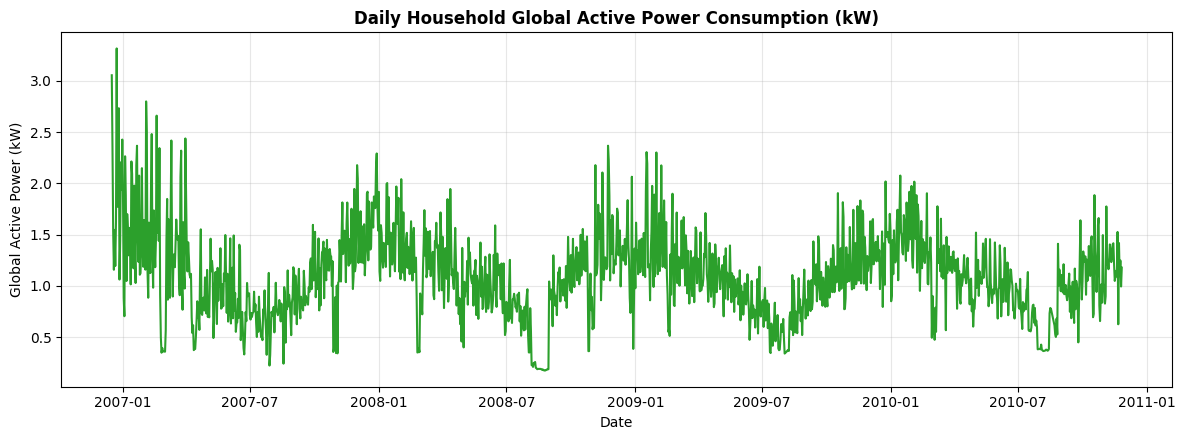

In [4]:
# ======================================================
# STEP 3: DATA CLEANING & DAILY RESAMPLING
# ======================================================
print("--- STEP 3: DATA CLEANING & DAILY RESAMPLING ---")

# Convert Global_active_power to float numeric values
raw_df['Global_active_power'] = pd.to_numeric(raw_df['Global_active_power'], errors='coerce')

# Convert Date column to datetime
raw_df['Date'] = pd.to_datetime(raw_df['Date'], format='%d/%m/%Y')

# Group by Date and compute daily mean active power
daily_df = raw_df.groupby('Date')['Global_active_power'].mean().reset_index()
daily_df = daily_df.dropna().sort_values('Date').reset_index(drop=True)

print(f"Clean Daily Dataset Shape: {daily_df.shape}")
print("First 5 rows of Daily Power Data:")
print(daily_df.head())

# Plot historical daily power consumption over time
plt.figure(figsize=(12, 4.5))
plt.plot(daily_df['Date'], daily_df['Global_active_power'], color='#2ca02c', linewidth=1.5)
plt.title("Daily Household Global Active Power Consumption (kW)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 4: Data Normalization & Sequence Creation</h2>

### 💡 Why Normalization & Sequences?
- <b>MinMaxScaler</b>: Scales electricity values between <code>0</code> and <code>1</code> for stable gradient flow in LSTM cells.
- <b>Sliding Window (30 Days)</b>:
  - <b>Input ($X$)</b>: Sequence of 30 past days of electricity consumption.
  - <b>Target ($y$)</b>: Electricity consumption on the 31st day!
- <b>Train / Test Split</b>: 80% of days for training, 20% for testing.

In [5]:
# ======================================================
# STEP 4: FEATURE SCALING & SEQUENCE CREATION
# ======================================================
print("--- STEP 4: SCALING & SEQUENCE CREATION ---")

power_values = daily_df[['Global_active_power']].values

# Scale values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_power = scaler.fit_transform(power_values)

# Create 30-day sliding window sequences
SEQ_LENGTH = 30
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_power, SEQ_LENGTH)

# 80% Train / 20% Test Split
train_size = int(0.8 * len(X_all))
X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test, y_test = X_all[train_size:], y_all[train_size:]

print(f"Total Sequences Created: {len(X_all)}")
print(f"Training Sequences   - X shape: {X_train.shape}, y shape: {y_train.shape}")
print(f"Testing Sequences    - X shape: {X_test.shape}, y shape: {y_test.shape}")

--- STEP 4: SCALING & SEQUENCE CREATION ---
Total Sequences Created: 1403
Training Sequences   - X shape: (1122, 30, 1), y shape: (1122, 1)
Testing Sequences    - X shape: (281, 30, 1), y shape: (281, 1)


<h2>Step 5: PyTorch Datasets & DataLoaders</h2>

We wrap our sequence tensors into PyTorch <code>TensorDataset</code> and <code>DataLoader</code> objects with <code>batch_size = 32</code>.

In [6]:
# ======================================================
# STEP 5: PYTORCH DATALOADERS
# ======================================================
print("--- STEP 5: CREATING PYTORCH DATALOADERS ---")

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders successfully created with Batch Size = {BATCH_SIZE}!")

--- STEP 5: CREATING PYTORCH DATALOADERS ---
DataLoaders successfully created with Batch Size = 32!


<h2>Step 6: Simple LSTM Architecture Definition</h2>

Here we build a beginner-friendly <b>LSTM (Long Short-Term Memory)</b> network in PyTorch.

### 💡 LSTM Architecture Explained:
- <b><code>nn.LSTM(input_size=1, hidden_size=64, num_layers=1, batch_first=True)</code></b>:
  - <b><code>hidden_size=64</code></b>: Number of memory neurons.
  - <b>Cell State ($c_0$) & Hidden State ($h_0$)</b>: Initialized to zero tensors.
  - The LSTM cell computes internal gate activations (Forget, Input, Cell, Output) across all 30 time steps.
- <b><code>nn.Linear(64, 1)</code></b>: Takes the last hidden state output and predicts next day's power consumption.

In [7]:
# ======================================================
# STEP 6: SIMPLE LSTM MODEL CLASS DEFINITION
# ======================================================
print("--- STEP 6: BUILDING LSTM ARCHITECTURE ---")

class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(SimpleLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Recurrent Layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Linear Output Layer
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize hidden state (h0) and cell state (c0) with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Pass through LSTM layer
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # Extract output of the LAST time step (out[:, -1, :])
        out = self.fc(out[:, -1, :])
        return out

model = SimpleLSTM(input_size=1, hidden_size=64, num_layers=1, output_size=1).to(device)
print("LSTM Model Architecture Summary:")
print(model)

--- STEP 6: BUILDING LSTM ARCHITECTURE ---
LSTM Model Architecture Summary:
SimpleLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


<h2>Step 7: Loss Function & Optimizer</h2>

1. <b>Loss Function</b>: <code>nn.MSELoss()</code> (Mean Squared Error).
2. <b>Optimizer</b>: <code>torch.optim.Adam(model.parameters(), lr=0.001)</code>.

In [8]:
# ======================================================
# STEP 7: LOSS FUNCTION & OPTIMIZER
# ======================================================
print("--- STEP 7: SETTING UP LOSS & OPTIMIZER ---")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss Function: Mean Squared Error (MSELoss)")
print("Optimizer: Adam (learning rate = 0.001)")

--- STEP 7: SETTING UP LOSS & OPTIMIZER ---
Loss Function: Mean Squared Error (MSELoss)
Optimizer: Adam (learning rate = 0.001)


<h2>Step 8: Model Training Loop & Loss Curve</h2>

We train the LSTM for <b>35 Epochs</b> and plot the loss convergence curve.

--- STEP 8: TRAINING LSTM MODEL ---
Starting LSTM Training Loop...
Epoch [01/35] | Training MSE Loss: 0.025640
Epoch [05/35] | Training MSE Loss: 0.011007
Epoch [10/35] | Training MSE Loss: 0.010234
Epoch [15/35] | Training MSE Loss: 0.010364
Epoch [20/35] | Training MSE Loss: 0.010002
Epoch [25/35] | Training MSE Loss: 0.009870
Epoch [30/35] | Training MSE Loss: 0.009621
Epoch [35/35] | Training MSE Loss: 0.009844
LSTM Training Complete!


<string>:44: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


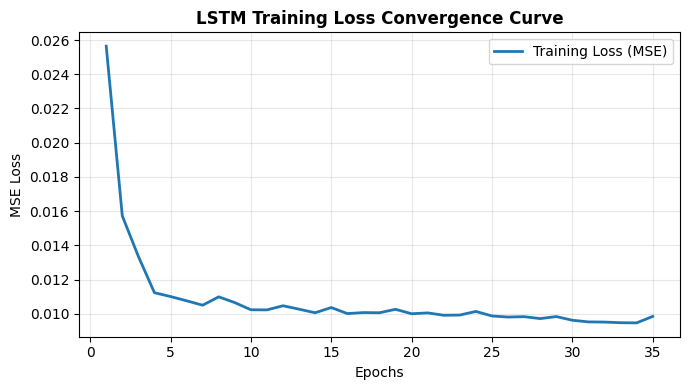

In [9]:
# ======================================================
# STEP 8: TRAINING THE LSTM MODEL
# ======================================================
print("--- STEP 8: TRAINING LSTM MODEL ---")

epochs = 35
train_losses = []

print("Starting LSTM Training Loop...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for seq_batch, target_batch in train_loader:
        seq_batch, target_batch = seq_batch.to(device), target_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(seq_batch)
        loss = criterion(predictions, target_batch)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * seq_batch.size(0)
        
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Training MSE Loss: {epoch_loss:.6f}")

print("LSTM Training Complete!")

# Plot Loss Curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (MSE)', color='#1f77b4', linewidth=2)
plt.title("LSTM Training Loss Convergence Curve", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 9: Test Evaluation & Actual vs. Predicted Power Plot</h2>

We evaluate the trained LSTM on the test set sequences.
We inverse transform the scaled values back to real kilowatts (kW) using <code>scaler.inverse_transform()</code> and plot <b>Actual vs. LSTM Predicted Electricity Consumption</b>!

--- STEP 9: TEST EVALUATION & FORECAST PLOT ---


<string>:35: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


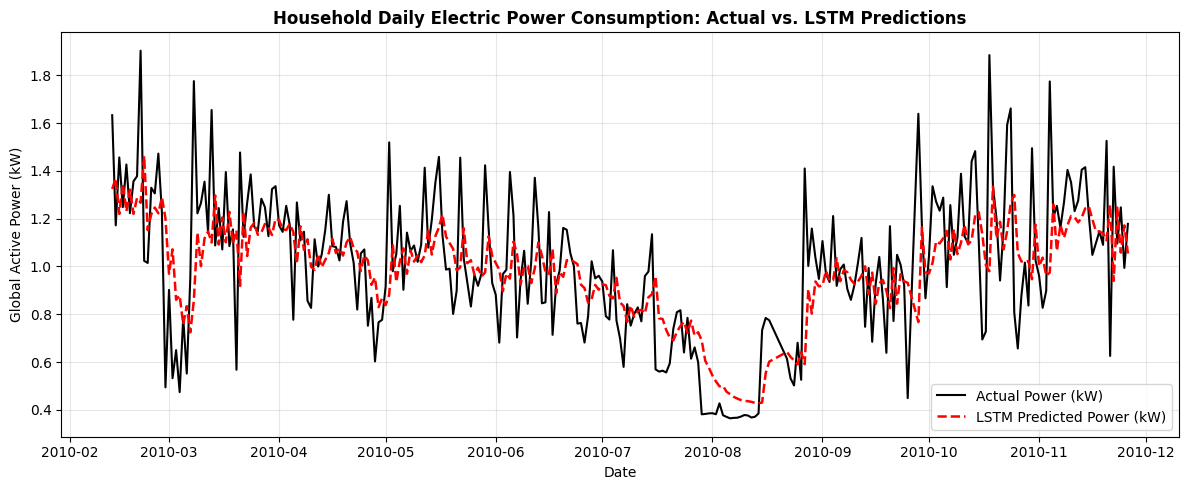

In [10]:
# ======================================================
# STEP 9: TEST EVALUATION & FORECAST PLOT
# ======================================================
print("--- STEP 9: TEST EVALUATION & FORECAST PLOT ---")

model.eval()
predictions_list = []
actuals_list = []

with torch.no_grad():
    for seq_batch, target_batch in test_loader:
        seq_batch = seq_batch.to(device)
        preds = model(seq_batch)
        
        predictions_list.extend(preds.cpu().numpy())
        actuals_list.extend(target_batch.numpy())

# Inverse transform back to original kW scale
actual_power = scaler.inverse_transform(np.array(actuals_list))
predicted_power = scaler.inverse_transform(np.array(predictions_list))

# Corresponding test dates
test_dates = daily_df['Date'].values[-len(actual_power):]

# Plot Actual vs Predicted Power Consumption
plt.figure(figsize=(12, 5))
plt.plot(test_dates, actual_power, label='Actual Power (kW)', color='black', linewidth=1.5)
plt.plot(test_dates, predicted_power, label='LSTM Predicted Power (kW)', color='red', linestyle='--', linewidth=1.8)
plt.title("Household Daily Electric Power Consumption: Actual vs. LSTM Predictions", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Step 10: Evaluation Metrics (MSE, RMSE, MAE)</h2>

We evaluate forecast accuracy using standard time-series regression metrics:
- <b>MSE (Mean Squared Error)</b>
- <b>RMSE (Root Mean Squared Error)</b> in kilowatts (kW)
- <b>MAE (Mean Absolute Error)</b> in kilowatts (kW)

In [11]:
# ======================================================
# STEP 10: CALCULATING EVALUATION METRICS
# ======================================================
print("--- STEP 10: FORECAST EVALUATION METRICS ---")

mse = mean_squared_error(actual_power, predicted_power)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_power, predicted_power)

metrics_df = pd.DataFrame({
    'Evaluation Metric': ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)'],
    'Value': [f"{mse:.4f}", f"{rmse:.4f} kW", f"{mae:.4f} kW"]
})

print("="*55)
print("LSTM POWER CONSUMPTION FORECASTING METRICS")
print("="*55)
print(metrics_df.to_string(index=False))
print("="*55)

--- STEP 10: FORECAST EVALUATION METRICS ---
LSTM POWER CONSUMPTION FORECASTING METRICS
             Evaluation Metric     Value
      Mean Squared Error (MSE)    0.0575
Root Mean Squared Error (RMSE) 0.2397 kW
     Mean Absolute Error (MAE) 0.1740 kW
